# International Football Match Outcome Prediction
## INFOH410 Project: Comparison of 3 AI Approaches

**Group 14:**
- Amine Bâaj
- Thierno Diallo
- Henock Mbolitumbalani Likoyo

**Goal**: predict the outcome of an international football match (Home win / Draw / Away win) using three different AI techniques:
1. **Naive Bayes**
2. **Decision Tree**
3. **Neural Network (MLP)**

---
## 1. Imports

We import the librairies needed.

In [1]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---
## 2. Loading the dataset

We use the "International Football Results from 1872 to 2026" dataset on Kaggle, a comprehensive collection of nearly 50,000 international football matches national teams.

Source: https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017

### 2.1. Dataset structure

The file `result.csv` contains one row per international match with the following columns:

|Column|Meaning|
|---|---|
|`date`|Date of the match (YYYY-MM-DD)|
|`home_team`|Name of the home team (e.g., "Brazil")|
|`away_team`|Name of the away team (e.g., "Germany")|
|`home_score`|Goals scored by the home team|
|`away_score`|Goals scored by the away team|
|`tournament`|Type of competition (e.g., "FIFA World Cup", "Friendly", "UEFA Euro qualification")|
|`city`|City where the match was played|
|`country`|Country where the match was played|
|`neutral`|`True` if played on neutral ground (no home advantage)|

In [2]:
DATA_PATH = '../data/results.csv'

# read the raw files and clean problematic commas (example: Washington, D.C.)
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    content = f.read()

# regex: find any "..., ..." pattern and remove the quotes + internal comma
content_clean = re.sub(r'"([^"]*),\s*([^"]*)"', r'\1 \2', content)

# save the cleaned version to a new file
CLEAN_PATH = '../data/results_clean.csv'
with open(CLEAN_PATH, 'w', encoding='utf-8') as f:
    f.write(content_clean)

# now load the cleaned CSV
df = pd.read_csv(CLEAN_PATH)

# basic info
print(f"Dataset loaded: {df.shape[0]} matches, {df.shape[1]} columns")
print(f"Date range: {df['date'].min()} -> {df['date'].max()}\n")

df.head()

Dataset loaded: 49287 matches, 9 columns
Date range: 1872-11-30 -> 2026-06-27



,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


---
## 3. Data analysis

Before building any model, we explore the dataset to understand its structure, detect anomalies and motivate our preprocessing decisions.

### 3.1. Basic statistics and missing values

We first convert the `date` column to a proper datetime type, sort the data chronologically and check for missing values or anomalies.

In [3]:
# convert date column to datetime type 
df['date'] = pd.to_datetime(df['date'])

# sort chronoligically 
df = df.sort_values('date').reset_index(drop=True)

# check column types
print("Column types:")
print(df.dtypes)

# check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Column types:
date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

Missing values per column:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


### 3.2. Cleaning: removing matches without scores

The dataset contains 72 matches with missing scores, these are future matches scheduled but not played (e.g., upcoming 2026 World Cup).

In [4]:
# count rows before cleaning
n_before = len(df)

# remove matches with missing scores
df = df.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

# convert scores back to integers
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)

n_after = len(df)

print(f"removed {n_before - n_after} matches with missing socres")
print(f"Final dataset: {n_after} matches")
print("\nUpdated column types:")
print(df.dtypes)

removed 72 matches with missing socres
Final dataset: 49215 matches

Updated column types:
date          datetime64[ns]
home_team             object
away_team             object
home_score             int64
away_score             int64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object


### 3.3. Temporal coverage

The dataset covers than 150 years of international football. We analyze how matches are distributed over time on a relevant time window for our models.

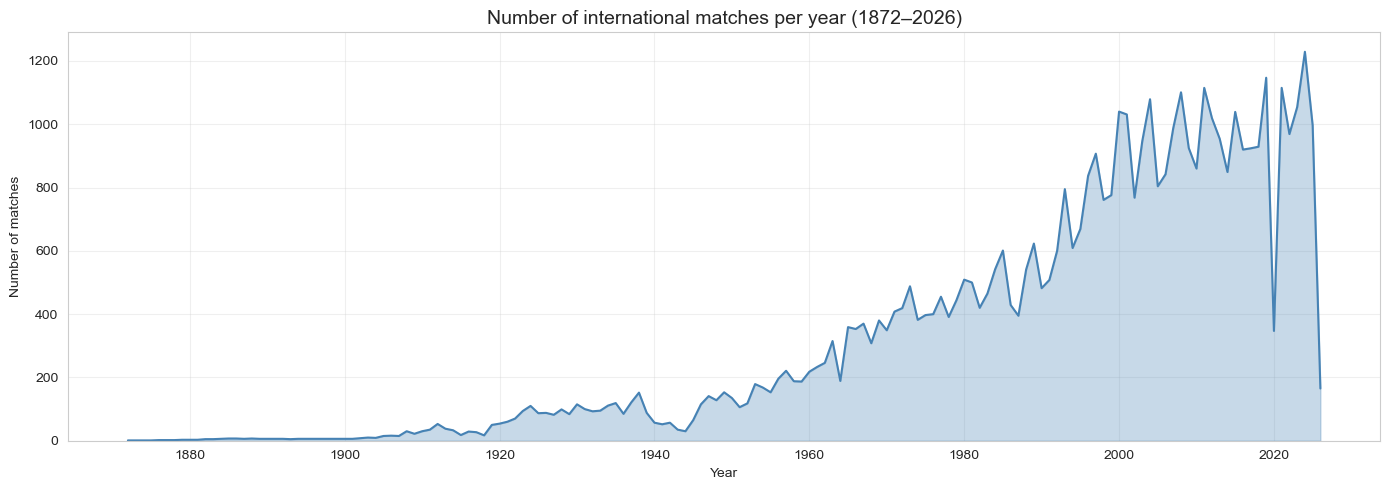

Total years covered: 154
Average matches per year: 318
Year with most matches: 2024 (1229 matches)
Year with fewest matches: 1872 (1 matches)


In [5]:
# extract year from each match
df['year'] = df['date'].dt.year

# count matches per year
matches_per_year = df.groupby('year').size()

# plot the distribution
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(matches_per_year.index, matches_per_year.values, color='steelblue', linewidth=1.5)
ax.fill_between(matches_per_year.index, matches_per_year.values, alpha=0.3, color='steelblue')

ax.set_title("Number of international matches per year (1872–2026)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Number of matches")
ax.set_ylim(0,)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total years covered: {df['year'].max() - df['year'].min()}")
print(f"Average matches per year: {matches_per_year.mean():.0f}")
print(f"Year with most matches: {matches_per_year.idxmax()} ({matches_per_year.max()} matches)")
print(f"Year with fewest matches: {matches_per_year.idxmin()} ({matches_per_year.min()} matches)")

### 3.4. Distribution of match outcomes

We now derive our target variable `result` from the scores:
- `H` if `home_score > away_score` (Home win)
- `D` if `home_score == away_score` (Draw)
- `A` if `home_score < away_score` (Away win)

Analyzing the distribution of `result`reveals two phenomena:
1. **Home advantage:** teams playing at home tend to win more often
2. **Class imbalance:** draw are less frequent than wins

In [6]:
# derive the target variable from the scores
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'H'
    elif row['home_score'] < row['away_score']:
        return 'A'
    else:
        return 'D'

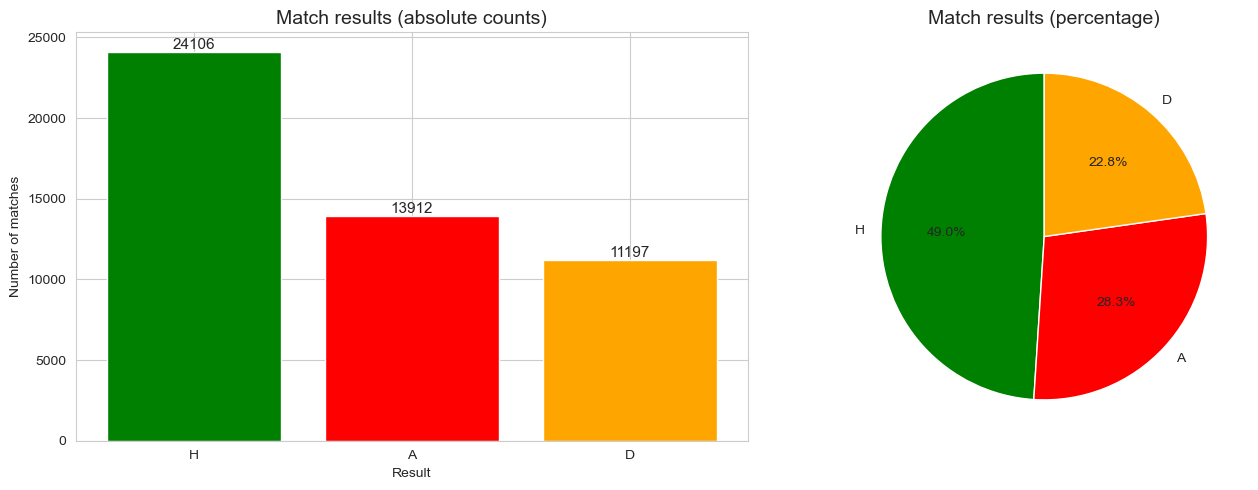

In [7]:
result_values = ['H', 'D', 'A']

df['result'] = df.apply(get_result, axis=1)

# count the distribution
result_counts = df['result'].value_counts()
result_percentage = df['result'].value_counts(normalize=True) * 100

# plot the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart
colors = {'H': 'green', 'D': 'orange', 'A': 'red'}
axes[0].bar(result_counts.index, result_counts.values, color=[colors[r] for r in result_counts.index])
axes[0].set_title("Match results (absolute counts)", fontsize=14)
axes[0].set_xlabel("Result")
axes[0].set_ylabel("Number of matches")
for i, (r, v) in enumerate(result_counts.items()):
    axes[0].text(i, v + 200, f"{v}", ha='center', fontsize=11)

# pie chart
axes[1].pie(result_percentage.values, labels=result_percentage.index, colors=[colors[r] for r in result_percentage.index], autopct='%1.1f%%', startangle=90)
axes[1].set_title("Match results (percentage)", fontsize=14)

plt.tight_layout()
plt.show()

### 3.5. Impact of neutral ground on home advantage

When a match is played on neutral ground (e.g., World Cup, continental cup), the labels "home" and "away" are arbitrary, there is no real home advantage. We expect the H/D/A distribution to be much more balanced for these matches. We should treat neutral matches differently to avoid teaching our models a false home advantage in these cases.

Matches with home advantage: 36239 (73.6%)
Matches on neutral ground: 12976 (26.4%)


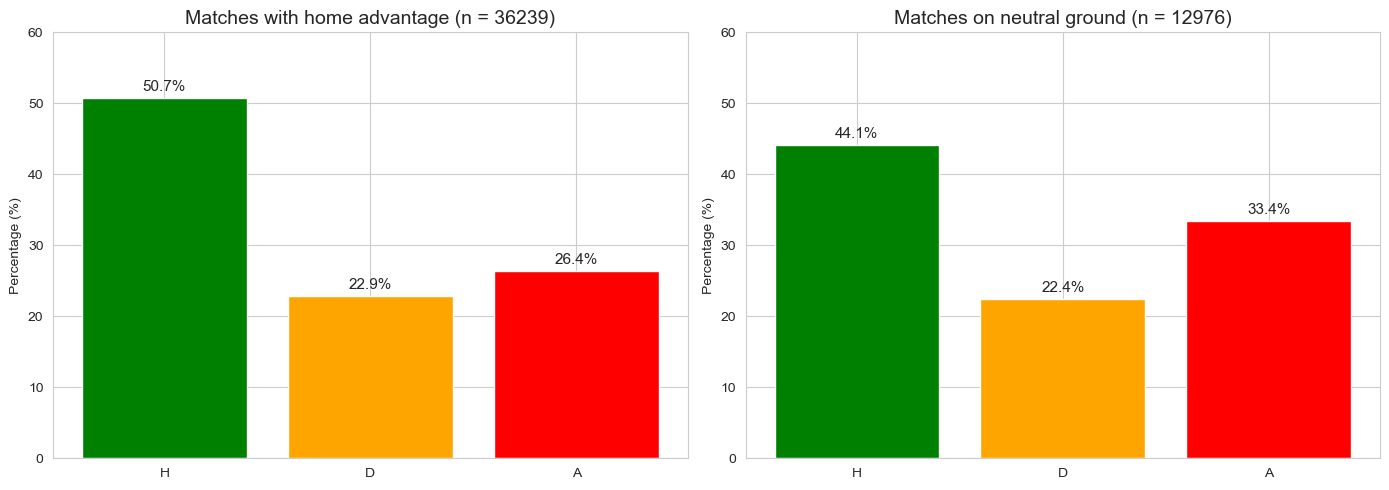

In [8]:
# split the dataset into neutral and non-neutral matches
df_home_advantage = df[df['neutral'] == False]
df_neutral = df[df['neutral'] == True]

print(f"Matches with home advantage: {len(df_home_advantage)} ({len(df_home_advantage)/len(df)*100:.1f}%)")
print(f"Matches on neutral ground: {len(df_neutral)} ({len(df_neutral)/len(df)*100:.1f}%)")

# compute distributions
percentage_home_adv = df_home_advantage['result'].value_counts(normalize=True) * 100
percentage_neutral = df_neutral['result'].value_counts(normalize=True) * 100

# comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# non-neutral
axes[0].bar(result_values, [percentage_home_adv.get(r, 0) for r in result_values], color=[colors[r] for r in result_values])
axes[0].set_title(f"Matches with home advantage (n = {len(df_home_advantage)})", fontsize=14)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, 60)
for i, r in enumerate(result_values):
    axes[0].text(i, percentage_home_adv.get(r, 0) + 1, f"{percentage_home_adv.get(r, 0):.1f}%", ha='center', fontsize=11)

# neutral
axes[1].bar(result_values, [percentage_neutral.get(r, 0) for r in result_values], color=[colors[r] for r in result_values])
axes[1].set_title(f"Matches on neutral ground (n = {len(df_neutral)})", fontsize=14)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 60)
for i, r in enumerate(result_values):
    axes[1].text(i, percentage_neutral.get(r, 0) + 1, f"{percentage_neutral.get(r, 0):.1f}%", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### 3.6. Goal distribution

We analyze how many goals are typically scored in international matches.

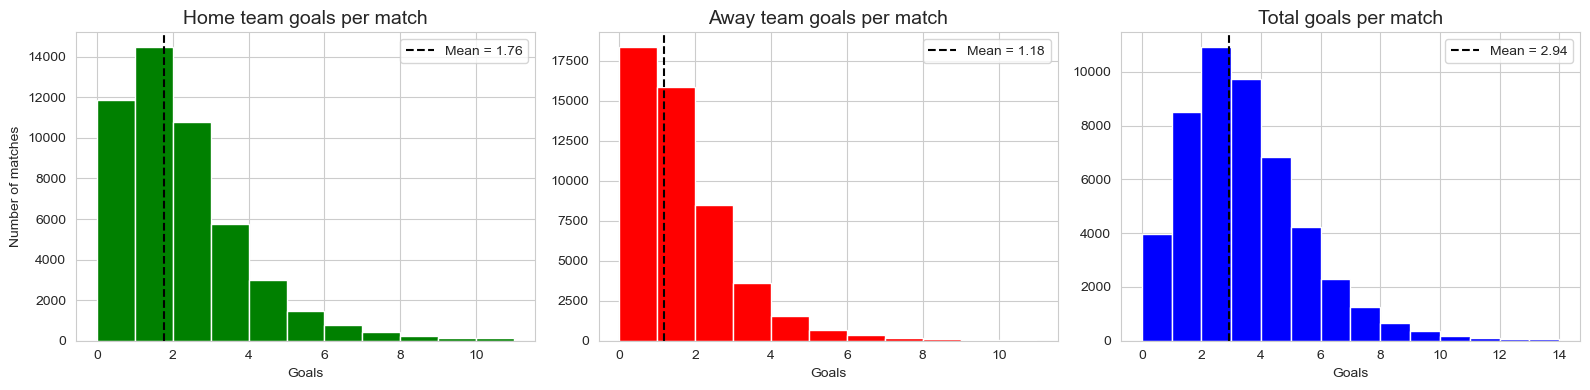


Most extreme matches:
      date home_team      away_team  home_score  away_score  total_goals
2001-04-11 Australia American Samoa          31           0           31
1971-09-13    Tahiti   Cook Islands          30           0           30
1979-08-30      Fiji       Kiribati          24           0           24
2001-04-09 Australia          Tonga          22           0           22
2006-11-24     Sápmi         Monaco          21           1           22


In [9]:
# total goals per match
df['total_goals'] = df['home_score'] + df['away_score']

# home vs away goals
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# home goals
axes[0].hist(df['home_score'], bins=range(0, 12), color='green')
axes[0].set_title("Home team goals per match", fontsize=14)
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("Number of matches")
axes[0].axvline(df['home_score'].mean(), color='black', linestyle='--', label=f"Mean = {df["home_score"].mean():.2f}")
axes[0].legend()

# away goals
axes[1].hist(df['away_score'], bins=range(0, 12), color='red')
axes[1].set_title("Away team goals per match", fontsize=14)
axes[1].set_xlabel("Goals")
axes[1].axvline(df['away_score'].mean(), color='black', linestyle='--', label=f"Mean = {df["away_score"].mean():.2f}")
axes[1].legend()

# total goals
axes[2].hist(df['total_goals'], bins=range(0, 15), color='blue')
axes[2].set_title("Total goals per match", fontsize=14)
axes[2].set_xlabel("Goals")
axes[2].axvline(df['total_goals'].mean(), color='black', linestyle='--', label=f"Mean = {df["total_goals"].mean():.2f}")
axes[2].legend()

plt.tight_layout()
plt.show()

# stats
print(f"\nMost extreme matches:")
top = df.nlargest(5, 'total_goals')[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'total_goals']]
print(top.to_string(index=False))

### 3.7. Most active teams and tournaments

We finally examine which teams play the most matches and what kinds of tournaments dominate the dataset.

Total unique teams in dataset: 333
Median matches per team: 231


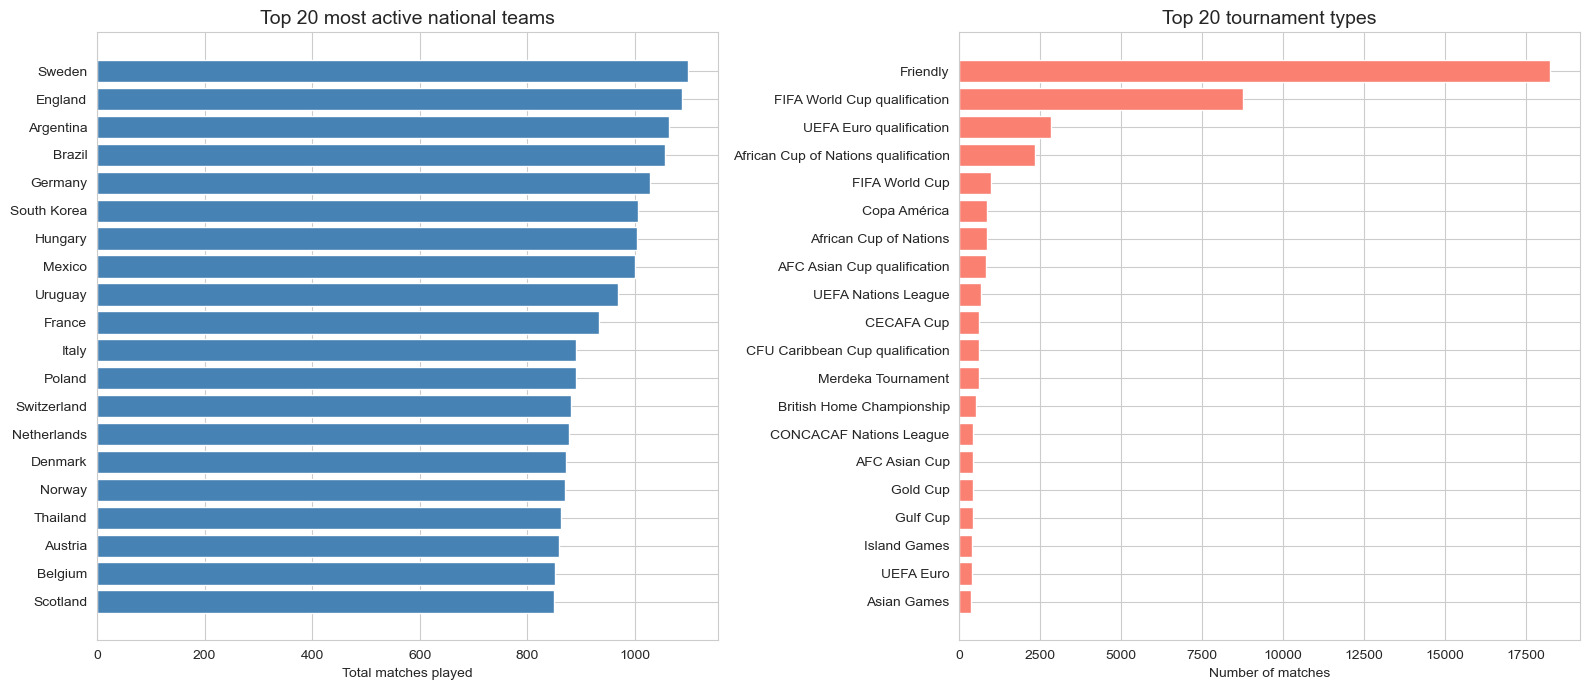


Friendly matches: 18252 (37.1%)
Competitive matches: 30963 (62.9%)


In [10]:
# combine home and away appearances to count total matches per team
home_counts = df['home_team'].value_counts()
away_counts = df['away_team'].value_counts()
all_appearances = home_counts.add(away_counts, fill_value=0).sort_values(ascending=False)

print(f"Total unique teams in dataset: {len(all_appearances)}")
print(f"Median matches per team: {all_appearances.median():.0f}")

# plot top teams + top tournaments
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# top 20 most active national teams
top_teams = all_appearances.head(20)
axes[0].barh(top_teams.index[::-1], top_teams.values[::-1], color='steelblue')
axes[0].set_title("Top 20 most active national teams", fontsize=14)
axes[0].set_xlabel("Total matches played")

# top 20 tournament types
top_tournaments = df['tournament'].value_counts().head(20)
axes[1].barh(top_tournaments.index[::-1], top_tournaments.values[::-1], color='salmon')
axes[1].set_title("Top 20 tournament types", fontsize=14)
axes[1].set_xlabel("Number of matches")

plt.tight_layout()
plt.show()

# summary about friendlies vs competitive
n_friendly  = (df['tournament'] == 'Friendly').sum()
n_competitive = len(df) - n_friendly
print(f"\nFriendly matches: {n_friendly} ({n_friendly/len(df)*100:.1f}%)")
print(f"Competitive matches: {n_competitive} ({n_competitive/len(df)*100:.1f}%)")

---
## 4. Building predictive features

Now that we understand the data, we will transform it into a format suitable for models. Recall our strategy: each match is encoded as a vector of statistical features computed from the recent history of both teams.

### 4.1. Temporal filtering

The dataset covers 1872–2026, but football has changed enormously over 150 years (rules, tactics, etc). Including very old matches would teach our models patterns that no longer apply. We restrict the analysis to matches from 2000 onwards. This Ensures homogeneous data from the modern football era.

In [11]:
# keep only matches from 2000-01-01 onwards
START_YEAR = 2000
n_before = len(df)

df = df[df['date'] >= f'{START_YEAR}-01-01'].reset_index(drop=True)

n_after = len(df)

print(f"Filter applied: matches from {START_YEAR} onwards")
print(f"  Before: {n_before} matches")
print(f"  After: {n_after} matches ({n_after/n_before*100:.1f}% kept)")
print(f"\nDate range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"\nNew result distribution:")
print(df['result'].value_counts(normalize=True).round(3))

Filter applied: matches from 2000 onwards
  Before: 49215 matches
  After: 25157 matches (51.1% kept)

Date range: 2000-01-04 -> 2026-03-31

New result distribution:
result
H    0.481
A    0.286
D    0.233
Name: proportion, dtype: float64


### 4.2. Recent team performance

For each match, we want to know how each team has been performing recently, before the match takes place. This is the most important set of features in our model.

#### 4.2.1. Function to retrieve a team's history

We define a function that given a team and a date returns the team's last N matches before that date.

In [12]:
def get_team_last_matches(df, team, before_date, n=10):
    mask = ((df['home_team'] == team) | (df['away_team'] == team)) & (df['date'] < before_date)
    history = df.loc[mask].sort_values('date').tail(n)
    return history


# test: get Brazil's last 10 matches before the 2014 World Cup final
test_history = get_team_last_matches(df, 'Brazil', pd.Timestamp('2014-07-13'), n=10)
print("Brazil's last 10 matches before the 2014 World Cup final:")
print(test_history[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament']].to_string(index=False))

Brazil's last 10 matches before the 2014 World Cup final:
      date    home_team   away_team  home_score  away_score     tournament
2014-03-05 South Africa      Brazil           0           5       Friendly
2014-06-03       Brazil      Panama           4           0       Friendly
2014-06-06       Brazil      Serbia           1           0       Friendly
2014-06-12       Brazil     Croatia           3           1 FIFA World Cup
2014-06-17       Brazil      Mexico           0           0 FIFA World Cup
2014-06-23       Brazil    Cameroon           4           1 FIFA World Cup
2014-06-28       Brazil       Chile           1           1 FIFA World Cup
2014-07-04       Brazil    Colombia           2           1 FIFA World Cup
2014-07-08       Brazil     Germany           1           7 FIFA World Cup
2014-07-12       Brazil Netherlands           0           3 FIFA World Cup


#### 4.2.2. Compute aggregated statistics from a team's history

Given a list of past matches for a team, we compute summary statistics.

In [13]:
def compute_team_stats(history, team):

    if len(history) == 0:
        # no history available -> return zeros
        return {'matches_played': 0, 'wins': 0, 'draws': 0, 'losses': 0, 'goals_scored': 0.0, 'goals_conceded': 0.0, 'goal_diff': 0.0, 'points': 0.0}

    wins = draws = losses = 0
    goals_scored = goals_conceded = 0

    for _, m in history.iterrows():
        # determine whether team was home or away in this past match
        if m['home_team'] == team:
            scored = m['home_score']
            conceded = m['away_score']
        else:
            scored = m['away_score']
            conceded = m['home_score']

        goals_scored   += scored
        goals_conceded += conceded

        # did the team win, draw, or lose ?
        if scored > conceded:
            wins += 1
        elif scored < conceded:
            losses += 1
        else:
            draws += 1

    n = len(history)
    return {
        'matches_played': n,
        'wins': wins,
        'draws': draws,
        'losses': losses,
        'goals_scored': goals_scored / n,
        'goals_conceded': goals_conceded / n,
        'goal_diff': (goals_scored - goals_conceded) / n,
        'points': (3 * wins + draws) / n
    }


# test on Brazil's pre-2014-final history
stats = compute_team_stats(test_history, 'Brazil')
print("Brazil's stats from the last 10 matches before 2014 final:")
for key, val in stats.items():
    if isinstance(val, float):
        print(f"  {key}: {val:.2f}")
    else:
        print(f"  {key}: {val}")

Brazil's stats from the last 10 matches before 2014 final:
  matches_played: 10
  wins: 6
  draws: 2
  losses: 2
  goals_scored: 2.10
  goals_conceded: 1.40
  goal_diff: 0.70
  points: 2.00


#### 4.2.3. Apply to the entire dataset

We now compute rolling features for every match in the dataset. For each match, we call our two helper functions twice, once for the home team, once for the away team.

For each match, we'll have **16 numerical features**:
- 8 features for the home team (`H_wins`, `H_goals_scored`, ...)
- 8 features for the away team (`A_wins`, `A_goals_scored`, ...)

Plus the original target `result`.

In [14]:
WINDOW_SIZE = 10 # number of past matches to consider

features_list = []

print(f"Computing features for {len(df)} matches...")

for _, row in df.iterrows():
    # get history for both teams
    home_history = get_team_last_matches(df, row['home_team'], row['date'], n=WINDOW_SIZE)
    away_history = get_team_last_matches(df, row['away_team'], row['date'], n=WINDOW_SIZE)

    # compute their stats
    home_stats = compute_team_stats(home_history, row['home_team'])
    away_stats = compute_team_stats(away_history, row['away_team'])

    # build a flat dict for this match
    feature_row = {
        'date': row['date'],
        'home_team': row['home_team'],
        'away_team': row['away_team'],
        'neutral': row['neutral'],
        'tournament': row['tournament'],
        'result': row['result'] # target
    }

    # prefix home stats with H_ and away stats with A_
    for key, val in home_stats.items():
        feature_row[f'H_{key}'] = val

    for key, val in away_stats.items():
        feature_row[f'A_{key}'] = val

    features_list.append(feature_row)

# convert list of dicts to DataFrame
df_features = pd.DataFrame(features_list)

print(f"Features dataframe shape: {df_features.shape}")

df_features.head()

Computing features for 25157 matches...
Features dataframe shape: (25157, 22)


,date,home_team,away_team,neutral,tournament,result,H_matches_played,H_wins,H_draws,H_losses,...,H_goal_diff,H_points,A_matches_played,A_wins,A_draws,A_losses,A_goals_scored,A_goals_conceded,A_goal_diff,A_points
0,2000-01-04,Egypt,Togo,False,Friendly,H,0,0,0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
1,2000-01-07,Tunisia,Togo,False,Friendly,H,0,0,0,0,...,0.0,0.0,1,0,0,1,1.0,2.0,-1.0,0.0
2,2000-01-08,Trinidad and Tobago,Canada,False,Friendly,D,0,0,0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
3,2000-01-09,Ivory Coast,Egypt,False,Friendly,H,0,0,0,0,...,0.0,0.0,1,1,0,0,2.0,1.0,1.0,3.0
4,2000-01-09,Mexico,Iran,True,Friendly,H,0,0,0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0


### 4.3. Filter matches with insufficient history

The first matches of our filtered dataset (Jan 2000) have no available history because we discarded all matches before 2000. These matches have all features at zero, which would teach our models nothing useful. We require both teams to have at least 5 past matches in their history.

In [15]:
# required minimum number of past matches for both teams
MIN_HISTORY = 5

n_before = len(df_features)

# keep only matches where both teams have at least MIN_HISTORY past games
mask = (df_features['H_matches_played'] >= MIN_HISTORY) & (df_features['A_matches_played'] >= MIN_HISTORY)

df_features = df_features[mask].reset_index(drop=True)

n_after = len(df_features)
print(f"Filtered out matches with insufficient history (< {MIN_HISTORY} past games)")
print(f"  Before: {n_before} matches")
print(f"  After: {n_after} matches ({n_after/n_before*100:.1f}% kept)")

print(f"\nNew date range: {df_features['date'].min().date()} -> {df_features['date'].max().date()}")

print(f"\nResult distribution:")
print(df_features['result'].value_counts(normalize=True).round(3))

print(f"\nMinimum H_matches_played = {df_features['H_matches_played'].min()}")
print(f"Minimum A_matches_played = {df_features['A_matches_played'].min()}")

df_features.head()

Filtered out matches with insufficient history (< 5 past games)
  Before: 25157 matches
  After: 24095 matches (95.8% kept)

New date range: 2000-02-01 -> 2026-03-31

Result distribution:
result
H    0.479
A    0.287
D    0.235
Name: proportion, dtype: float64

Minimum H_matches_played = 5
Minimum A_matches_played = 5


,date,home_team,away_team,neutral,tournament,result,H_matches_played,H_wins,H_draws,H_losses,...,H_goal_diff,H_points,A_matches_played,A_wins,A_draws,A_losses,A_goals_scored,A_goals_conceded,A_goal_diff,A_points
0,2000-02-01,Egypt,Burkina Faso,True,African Cup of Nations,H,5,3,0,2,...,0.2,1.8,5,1,3,1,1.200000,1.400000,-0.200000,1.200000
1,2000-02-07,Egypt,Tunisia,True,African Cup of Nations,A,6,4,0,2,...,0.5,2.0,5,2,1,2,2.000000,1.200000,0.800000,1.400000
2,2000-02-10,Cameroon,Tunisia,True,African Cup of Nations,H,6,2,3,1,...,0.5,1.5,6,3,1,2,1.833333,1.000000,0.833333,1.666667
3,2000-02-12,South Africa,Tunisia,True,African Cup of Nations,D,5,3,1,1,...,0.4,2.0,7,3,1,3,1.571429,1.285714,0.285714,1.428571
4,2000-02-13,Nigeria,Cameroon,False,African Cup of Nations,D,5,4,1,0,...,1.4,2.6,7,3,3,1,1.571429,0.714286,0.857143,1.714286


### 4.4. Encoding non-numerical features

Two of our columns are non-numerical: `neutral` (boolean) and `tournament` (string). We encode them into numbers so the models can use them:

- `neutral` -> `is_neutral` (1 if neutral ground, 0 otherwise)
- `tournament` -> `is_competitive` (1 if competitive, 0 if friendly)

In [16]:
# encode 'neutral' as 0/1
df_features['is_neutral'] = df_features['neutral'].astype(int)

# encode 'tournament' as 0 (friendly) / 1 (competitive)
df_features['is_competitive'] = (df_features['tournament'] != 'Friendly').astype(int)

# verify the encoding
print("neutral encoding:")
print(df_features['is_neutral'].value_counts())
print(f"  Mean: {df_features['is_neutral'].mean():.3f} (proportion of neutral matches)")

print("\ntournament encoding (friendly vs competitive):")
print(df_features['is_competitive'].value_counts())
print(f"  Mean: {df_features['is_competitive'].mean():.3f} (proportion of competitive matches)")

neutral encoding:
is_neutral
0    17349
1     6746
Name: count, dtype: int64
  Mean: 0.280 (proportion of neutral matches)

tournament encoding (friendly vs competitive):
is_competitive
1    16170
0     7925
Name: count, dtype: int64
  Mean: 0.671 (proportion of competitive matches)


### 4.6. Building the feature matrix X and target vector y

We assemble the final inputs for our models:
- `X`: the 18-feature matrix used for training
- `y`: the target labels (`H`, `D`, `A`)

We drop the metadata columns (`date`, `home_team`, `away_team`, `tournament`, `neutral`).

In [17]:
# define the feature columns
FEATURE_COLS = [
    'H_matches_played', 
    'H_wins', 
    'H_draws', 
    'H_losses',
    'H_goals_scored', 
    'H_goals_conceded', 
    'H_goal_diff', 
    'H_points',
    'A_matches_played', 
    'A_wins', 
    'A_draws', 
    'A_losses',
    'A_goals_scored', 
    'A_goals_conceded', 
    'A_goal_diff', 
    'A_points',
    'is_neutral', 
    'is_competitive'
]

# build X and y
X = df_features[FEATURE_COLS].copy()
y = df_features['result'].copy()

# checks
print(f"Feature matrix X: {X.shape} (n_matches × n_features)")
print(f"Target vector  y: {y.shape}")
print(f"\nFeatures used ({len(FEATURE_COLS)} total):")
for i, col in enumerate(FEATURE_COLS):
    print(f"  {i+1}. {col}")

print(f"\nX data types:")
print(X.dtypes.value_counts())

print(f"\ny class distribution:")
print(y.value_counts(normalize=True).round(3))

# first few rows of the final X
print(f"\nFirst 3 rows of X:")
X.head(3)

Feature matrix X: (24095, 18) (n_matches × n_features)
Target vector  y: (24095,)

Features used (18 total):
  1. H_matches_played
  2. H_wins
  3. H_draws
  4. H_losses
  5. H_goals_scored
  6. H_goals_conceded
  7. H_goal_diff
  8. H_points
  9. A_matches_played
  10. A_wins
  11. A_draws
  12. A_losses
  13. A_goals_scored
  14. A_goals_conceded
  15. A_goal_diff
  16. A_points
  17. is_neutral
  18. is_competitive

X data types:
int64      10
float64     8
Name: count, dtype: int64

y class distribution:
result
H    0.479
A    0.287
D    0.235
Name: proportion, dtype: float64

First 3 rows of X:


,H_matches_played,H_wins,H_draws,H_losses,H_goals_scored,H_goals_conceded,H_goal_diff,H_points,A_matches_played,A_wins,A_draws,A_losses,A_goals_scored,A_goals_conceded,A_goal_diff,A_points,is_neutral,is_competitive
0,5,3,0,2,1.000000,0.800000,0.2,1.8,5,1,3,1,1.200000,1.4,-0.200000,1.200000,1,1
1,6,4,0,2,1.500000,1.000000,0.5,2.0,5,2,1,2,2.000000,1.2,0.800000,1.400000,1,1
2,6,2,3,1,1.333333,0.833333,0.5,1.5,6,3,1,2,1.833333,1.0,0.833333,1.666667,1,1


### 4.7. Train/test split

For time-series data, a random split would cause temporal data leakage. We split chronologically instead:

- **Train**: oldest 80% of matches
- **Test**: most recent 20%

This mirrors a realistic deployment: train on the past, predict the futur.

In [18]:
# sort by date one more time for safety
df_features = df_features.sort_values('date').reset_index(drop=True)
X = X.loc[df_features.index]
y = y.loc[df_features.index]

# compute the 80/20 chronological split point
split_ratio = 0.8
split_idx = int(len(df_features) * split_ratio)

# slice the data
X_train = X.iloc[:split_idx].reset_index(drop=True)
X_test  = X.iloc[split_idx:].reset_index(drop=True)
y_train = y.iloc[:split_idx].reset_index(drop=True)
y_test  = y.iloc[split_idx:].reset_index(drop=True)

# useful metadata for analysis
train_dates = df_features['date'].iloc[:split_idx]
test_dates  = df_features['date'].iloc[split_idx:]

print(f"Chronological 80/20 split:")
print(f"  Train set: {len(X_train)} matches ({train_dates.min().date()} -> {train_dates.max().date()})")
print(f"  Test set: {len(X_test)} matches ({test_dates.min().date()} -> {test_dates.max().date()})")

print(f"\nClass distribution in train:")
print(y_train.value_counts(normalize=True).round(3))

print(f"\nClass distribution in test:")
print(y_test.value_counts(normalize=True).round(3))

# the test set must be entirely AFTER the train set
assert train_dates.max() <= test_dates.min(), "TRAIN and TEST overlap in time!"
print(f"\nNo temporal overlap between train and test")

Chronological 80/20 split:
  Train set: 19276 matches (2000-02-01 -> 2021-09-07)
  Test set: 4819 matches (2021-09-07 -> 2026-03-31)

Class distribution in train:
result
H    0.480
A    0.284
D    0.236
Name: proportion, dtype: float64

Class distribution in test:
result
H    0.474
A    0.298
D    0.228
Name: proportion, dtype: float64

No temporal overlap between train and test


### 4.8. Saving the prepared data

Finally, we save the processed dataset to disk.

In [19]:
PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# save the four arrays
X_train.to_csv(f'{PROCESSED_DIR}/X_train.csv', index=False)
X_test.to_csv (f'{PROCESSED_DIR}/X_test.csv', index=False)
y_train.to_csv(f'{PROCESSED_DIR}/y_train.csv', index=False)
y_test.to_csv (f'{PROCESSED_DIR}/y_test.csv', index=False)

# save the full features dataframe with metadata
df_features.to_csv(f'{PROCESSED_DIR}/df_features.csv', index=False)

print(f"Saved processed data to '{PROCESSED_DIR}/'")

Saved processed data to '../data/processed/'
